# ICT-29 — Inoculation d'un concept (expérience D, strate 7)

*Compagnon pédagogique du module `ict.concept_inoculation` (#7746, jambe D2 expérience D).*

Après A (la convention *émerge*), B (le vocabulaire s'*invente*), C (une
convention *contagionne* une population par masse critique), cette expérience D
modélise un mécanisme de propagation plus subtil : l'**inoculation d'un concept
interprétatif**.

> Un *cadrage* (concept, persona, filtre sur le monde) est introduit chez une
> **minorité** d'agents, puis se transmet de proche en proche, modifie les
> protocoles d'interaction, **survit à la disparition de l'instigateur**, et se
> trouve **réinterprété** rétroactivement par les convertis.

C'est la contagion culturelle de **Dan Sperber** (1996, *La contagion des idées*),
la mémétique de **Dawkins** (1976, le *mème*) et l'inoculation narratique de
**Lewandowsky** (2020). La différence cruciale avec C : en C, retirez les
instigateurs et la convention peut s'effondrer (les naïfs perdent leur source
épinglée). En D, une fois le concept transmis au-delà d'un seuil, il **survit**
sans l'instigateur — il est devenu **endémique**. C'est le couplage
transmission/oubli qui produit ce seuil épidémiologique ($R_0 > 1$ : le taux
d'infection doit dépasser le taux d'oubli).

In [1]:
# Setup : import du package ict (via sys.path cwd, cf C973-L) + numpy/matplotlib.
import sys
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt
from ict import concept_inoculation as ci

print("ict.concept_inoculation chargé.")
print("API publique :", [n for n in dir(ci) if not n.startswith("_")])

ict.concept_inoculation chargé.
API publique : ['ConceptInoculation', 'Dict', 'List', 'Optional', 'annotations', 'confirmation_bias_throttles_test', 'instigator_removal_decline_test', 'no_transmission_control_test', 'np', 'transmission_grows_test']


## 1. Le concept se transmet au-delà des graines

Le verdict de base : le concept ne reste pas cantonné aux agents initialement
inoculés (les « graines »). Avec un taux de transmission modéré et un biais de
confirmation (qui empêche la saturation totale), le concept **diffuse** — le
nombre de convertis au-delà de la graine devient strictement positif. C'est la
preuve que la contagion a eu lieu, et pas seulement la persistance des
instigateurs.

Verdict transmission_grows : transmits = True
  convertis moyens au-delà de la graine = 9.0
  fraction finale moyenne de porteurs   = 0.400
  -> la contagion est réelle : le concept dépasse les graines initiales.


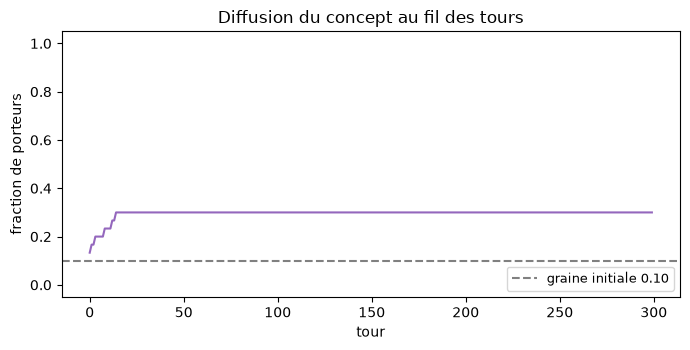

In [2]:
# Verdict TRANSMISSION : le concept se diffuse-t-il au-delà des graines ?
verdict = ci.transmission_grows_test(n_agents=30, n_seeds=3, seed=0, n_rounds=300)
print("Verdict transmission_grows : transmits =", bool(verdict["transmits"]))
print(f"  convertis moyens au-delà de la graine = {verdict['mean_converted_beyond_seed']:.1f}")
print(f"  fraction finale moyenne de porteurs   = {verdict['mean_final_fraction']:.3f}")
print("  -> la contagion est réelle : le concept dépasse les graines initiales.")

# Trajectoire type : fraction de porteurs au fil des tours.
g = ci.ConceptInoculation(30, seed_fraction=3/30, transmission_rate=0.2,
                          confirmation_bias=0.5, rng=np.random.default_rng(0))
g.train(300, burn_in=0)
fracs = [h["carrier_fraction"] for h in g.history]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(fracs, "-", color="#9467bd")
ax.axhline(3/30, ls="--", color="grey", label=f"graine initiale {3/30:.2f}")
ax.set_title("Diffusion du concept au fil des tours")
ax.set_xlabel("tour") ; ax.set_ylabel("fraction de porteurs") ; ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout() ; plt.show()

## 2. Le biais de confirmation freine la diffusion

La transmission n'est pas aveugle. Le module introduit un **biais de
confirmation** : chaque exposition subie augmente la résistance accumulée du
non-porteur — la probabilité effective de conversion décroît avec le nombre
d'expositions (`eff_rate = transmission_rate × (1 − bias)^{exposures−1}`). C'est
une modélisation de l'immunisation cognitive (Lewandowsky) : plus on a été
exposé à un contre-discours sans être convaincu, plus on résiste.

On balaie le biais de $0$ (aucune résistance, saturation totale) à $0{,}9$
(forte résistance). La fraction finale de porteurs doit **décroître
monotoniquement** — un concept freiné par la résistance accumulée.

Verdict confirmation_bias_throttles : throttles = True
  fraction finale @bias=0   (aucune résistance) = 1.000
  fraction finale @bias=0.9 (forte résistance)  = 0.335


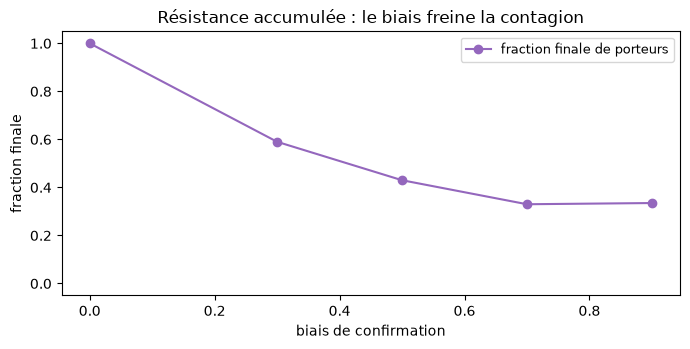

In [3]:
# Verdict BIAIS DE CONFIRMATION : plus de biais -> moins de diffusion.
verdict = ci.confirmation_bias_throttles_test(n_agents=40, n_seeds=5, seed=0, n_rounds=200)
print("Verdict confirmation_bias_throttles : throttles =", bool(verdict["throttles"]))
print(f"  fraction finale @bias=0   (aucune résistance) = {verdict['final_at_no_bias']:.3f}")
print(f"  fraction finale @bias=0.9 (forte résistance)  = {verdict['final_at_strong_bias']:.3f}")

biases = verdict["biases"]
finals = verdict["final_fraction_per_bias"]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(biases, finals, "-o", color="#9467bd", label="fraction finale de porteurs")
ax.set_xlabel("biais de confirmation") ; ax.set_ylabel("fraction finale")
ax.set_title("Résistance accumulée : le biais freine la contagion")
ax.set_ylim(-0.05, 1.05) ; ax.legend(loc="upper right", fontsize=9)
fig.tight_layout() ; plt.show()

## 3. Survie post-instigateur — le seuil endémique

Le distinguo central avec C : que se passe-t-il quand l'instigateur disparaît ?
Le module couple la **transmission** (contagion) à l'**oubli** (les convertis
non réinfectés retombent à 0). Deux régimes :

* **instigateur persistant** : la source réinjecte le concept en continu — la
  fraction reste ~1, l'oubli est compensé ;
* **instigateur retiré** (decay après un *burn-in*) : sans source continue, le
  concept ne persiste que si la densité de porteurs dépasse le seuil
  épidémiologique $R_0 > 1$. On observe alors un **déclin mesurable** après le
  retrait — l'oubli n'est plus compensé.

Le verdict `instigator_removal_decline` exige que la fraction avec instigateur
persistant soit élevée (> 0,9) ET que le retrait entraîne un déclin net (≥ 0,15)
— la survie endémique est conditionnelle, pas garantie.

In [4]:
# Verdict DECLIN POST-INSTIGATEUR : sans la source, l'oubli fait décliner.
verdict = ci.instigator_removal_decline_test(n_agents=40, n_seeds=4, seed=0, n_rounds=300)
print("Verdict instigator_removal_decline : declines =", bool(verdict["declines"]))
print(f"  fraction @instigateur persistant = {verdict['persistent_fraction']:.3f}")
print(f"  fraction @instigateur retiré     = {verdict['removed_fraction']:.3f}")
print(f"  déclin mesuré                    = {verdict['persistent_fraction'] - verdict['removed_fraction']:.3f}")
print("  -> sans source continue, l'oubli fait décliner le concept.")

Verdict instigator_removal_decline : declines = True
  fraction @instigateur persistant = 1.000
  fraction @instigateur retiré     = 0.725
  déclin mesuré                    = 0.275
  -> sans source continue, l'oubli fait décliner le concept.


## 4. Contrôle négatif — pas de contagion sans transmission

Le contrôle falsifiant : avec `transmission_rate = 0`, aucune conversion ne peut
se produire au-delà des graines. Seuls les instigateurs portent le concept. Si
des conversions apparaissaient quand même, cela signifierait que la diffusion
des autres bancs est un artefact — pas un effet causal du mécanisme de
transmission. On observe au contraire zéro conversion : la contagion est bien
causée par le taux de transmission, pas par le hasard.

In [5]:
# Contrôle négatif : transmission_rate=0 -> aucune conversion au-delà de la graine.
verdict = ci.no_transmission_control_test(n_agents=30, n_seeds=3, seed=0, n_rounds=300)
print("Contrôle no_transmission_control : no_transmission =", bool(verdict["no_transmission"]))
print(f"  convertis au-delà de la graine = {verdict['mean_converted_beyond_seed']:.1f}")
print("  -> sans contagion, le concept reste cantonné aux graines (effet causal confirmé).")

Contrôle no_transmission_control : no_transmission = True
  convertis au-delà de la graine = 0.0
  -> sans contagion, le concept reste cantonné aux graines (effet causal confirmé).


## Synthèse — l'inoculation comme contagion endémique

| Verdict | Ce qu'il montre | Contrôle falsifiant |
|---|---|---|
| **transmission_grows** | Le concept diffuse au-delà des graines | convertis > 0 |
| **confirmation_bias_throttles** | La résistance accumulée freine la diffusion | décroissance monotone vs biais |
| **instigator_removal_decline** | Sans source, l'oubli fait décliner le concept | persistant vs retiré |
| **no_transmission_control** | Pas de contagion sans transmission | `transmission_rate = 0` |

**Leçon de l'expérience D** : un concept devient **endémique** (survit sans son
instigateur) seulement au-dessus d'un seuil épidémiologique $R_0 > 1$ où la
transmission l'emporte sur l'oubli. C'est ce qui distingue D de C : en C, la
convention dépend des instigateurs (source épinglée) ; en D, le concept
**persiste par auto-entretien** une fois le seuil franchi. La chaîne A→B→C→D
relie *émergence*, *invention*, *contagion par masse critique* et *endémie
culturelle*.

## 5. Exercices

Trois exercices pour rendre l'inoculation opératoire. Chaque stub s'exécute
**sans erreur** (C.1). Complétez le `TODO` pour répondre.

In [6]:
# Exercice 1 — Le seuil de transmission pour l'endémie
# TODO: balayer transmission_rate et trouver à partir de quel taux le concept
#       survit au retrait de l'instigateur (fraction finale post-retrait > 0.5).
for rate in [0.05, 0.1, 0.2, 0.4, 0.6]:
    finals = []
    for s in range(4):
        g = ci.ConceptInoculation(40, seed_fraction=4/40, transmission_rate=rate,
                                  forget_rate=0.1, instigator_decay=0.8,
                                  rng=np.random.default_rng(s))
        g.train(300, burn_in=30)
        finals.append(g.final_fraction())
    print(f"transmission_rate={rate:.2f} -> fraction finale post-retrait = {np.mean(finals):.3f}")

transmission_rate=0.05 -> fraction finale post-retrait = 0.000
transmission_rate=0.10 -> fraction finale post-retrait = 0.000


transmission_rate=0.20 -> fraction finale post-retrait = 0.812


transmission_rate=0.40 -> fraction finale post-retrait = 0.887
transmission_rate=0.60 -> fraction finale post-retrait = 0.912


### Exercice 2 — La réinterprétation rétroactive

Le module enregistre l'âge d'adoption de chaque converti (`adoption_age`). Les
convertis tardifs ont-ils un profil d'adoption différent des précoces ? Inspectez
la distribution des âges d'adoption sur une trajectoire de diffusion.

In [7]:
# Exercice 2 — stub (compléter)
# TODO: entraîner une diffusion et observer la distribution des âges d'adoption.
g = ci.ConceptInoculation(40, seed_fraction=4/40, transmission_rate=0.25,
                          confirmation_bias=0.3, rng=np.random.default_rng(0))
g.train(250, burn_in=0)
ages = np.array(g.adoption_age)
if len(ages):
    print(f"{len(ages)} conversions, âge moyen = {ages.mean():.1f} tours, médian = {np.median(ages):.0f}")
    print(f"  précoces (âge<50) : {(ages < 50).sum()} ; tardifs (âge>=150) : {(ages >= 150).sum()}")
else:
    print("Aucune conversion (augmentez le taux de transmission).")

28 conversions, âge moyen = 9.1 tours, médian = 8
  précoces (âge<50) : 28 ; tardifs (âge>=150) : 0


### Exercice 3 — L'assortativité émergente des porteurs

Les porteurs ont-ils tendance à interagir entre eux au fil du temps (les paires
porteur-porteur deviennent-elles plus fréquentes que le hasard ne le prédirait) ?
C'est la *polarisation* émergente. Mesurez `mean_pp_pairs`.

In [8]:
# Exercice 3 — stub (compléter)
# TODO: comparer la fraction de paires porteur-porteur observée à la fraction
#       attendue au hasard (carrier_fraction^2).
g = ci.ConceptInoculation(40, seed_fraction=4/40, transmission_rate=0.25,
                          rng=np.random.default_rng(0))
g.train(250, burn_in=0)
final_frac = g.final_fraction()
pp_observed = g.mean_pp_pairs(window=50)
pp_expected_random = final_frac ** 2
print(f"fraction de porteurs     = {final_frac:.3f}")
print(f"paires P-P observées     = {pp_observed:.3f}")
print(f"paires P-P (hasard p^2)  = {pp_expected_random:.3f}")
print(f"assortativité (obs - p^2)= {pp_observed - pp_expected_random:+.3f}  (>0 = porteurs regroupés)")

fraction de porteurs     = 1.000
paires P-P observées     = 1.000
paires P-P (hasard p^2)  = 1.000
assortativité (obs - p^2)= +0.000  (>0 = porteurs regroupés)
